# Understanding CNN Principles for Beginners | PyTorch | MNIST

Formally, this is a notebook for participating in the educational competition "[Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer)" for handwritten digit recognition, but the actual purpose of this notebook is to explain the principles of convolutional neural networks to beginners. If you are just starting out with neural networks and don't fully understand how convolutional neural networks work yet, read this article — it might clarify things. You can study this material even if you've never worked with PyTorch before — all code is accompanied by detailed comments.

Tags: Beginners, NN, MLP, CNN, MNIST.

# Preparatory Steps

Environment setup code:

In [1]:
notebook_name = 'kaggle.com/code/palegreendot/juggling-mnist'
print(f"Hello from {notebook_name} notebook!\n")

# The Python environment on Kaggle already contains
# many necessary packages as per the image github.com/kaggle/docker-python

# PyTorch itself
import torch

# Ready-made building blocks for constructing neural networks
import torch.nn as nn
import torch.nn.functional as F

# Optimizers — algorithms designed to speed up and improve the efficiency of gradient descent
import torch.optim as optim

# For explaining the principles of convolutional neural networks
import torch.backends.cudnn as cudnn

# Access to ready-made datasets, including MNIST
from torchvision import datasets

# Transformations. For now we only need ToTensor()
from torchvision import transforms

# Combining data into batches, shuffling data during training, parallel data loading
from torch.utils.data import DataLoader

# NumPy. Not directly needed for neural network development;
# in this notebook it is used only for data visualization
import numpy as np

# Matplotlib. Also visualization
import matplotlib.pyplot as plt

# Utility functionality
import os
import time
import datetime

# Progress bar
import tqdm

import warnings
# Suppress the warning about hardware and software compatibility requirements
warnings.filterwarnings('ignore', category=UserWarning)
# Suppress the warning about the need to update methods
warnings.filterwarnings('ignore', category=DeprecationWarning)
# You could simply use warnings.filterwarnings('ignore') without specifying the category,
# but that's not a very good practice and may lead to subtle bugs in the code

# torchviz is not included in Kaggle's standard package set, so we need to use the "%pip install" directive
%pip install torchviz
# Visualization of neural network structure
from torchviz import make_dot

Hello from kaggle.com/code/palegreendot/juggling-mnist notebook!

Note: you may need to restart the kernel to use updated packages.


In [2]:
# This is the standard Kaggle incantation, reminding about certain limitations when working on the site
# Write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# Write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Input data files are available in the read-only "../input/" directory

# Check for the MNIST dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte
/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


## GPU Configuration

If you're working with data directly on the Kaggle website, don't forget to enable a GPU in the settings.

Computations can be done on CPU, but if a GPU is available it is **much** more far-sighted to set up and start using the GPU for calculations right away, otherwise the waiting time for results can grow indecently long.

In principle, for tinkering with simple models on a local machine you can use CPU, but unfortunately, even a fairly powerful i9-13900K, which I had at the time of writing this article, even on relatively minimalist datasets like MNIST operates rather sluggishly, making you want to stop hovering over it and go get some coffee.

If you want to use a GPU on your local machine but torch.cuda.is_available() returns False, you need to:  
check CUDA availability for your GPU at https://developer.nvidia.com/cuda/gpus  
install CUDA from https://developer.nvidia.com/cuda-downloads  
install PyTorch with GPU support from https://pytorch.org/get-started/locally. If you had previously installed "regular" CPU-only PyTorch — uninstall it.

Let's try:

In [3]:
print(torch.cuda.is_available())

# GPU characteristics
if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.current_device())
    print(torch.cuda.device(torch.cuda.current_device()))
    print(torch.cuda.get_device_name(0))

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

True
2
0
Tesla T4
Using cuda device


## Loading Datasets

In [4]:
# You can also try transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# using pre-calculated constants for MNIST (https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457)
transform = transforms.ToTensor()

# Training dataset
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

# Test dataset
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# The larger the batch_size, the faster the training process, but the worse the feedback, because
# the backpropagation process is triggered less frequently
# shuffle=True -> data will be fed in a different order each time. Useful for training
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# batch_size can be larger here; it no longer affects accuracy
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]

Train: 60000, Test: 10000


## Visualizing Loaded Data

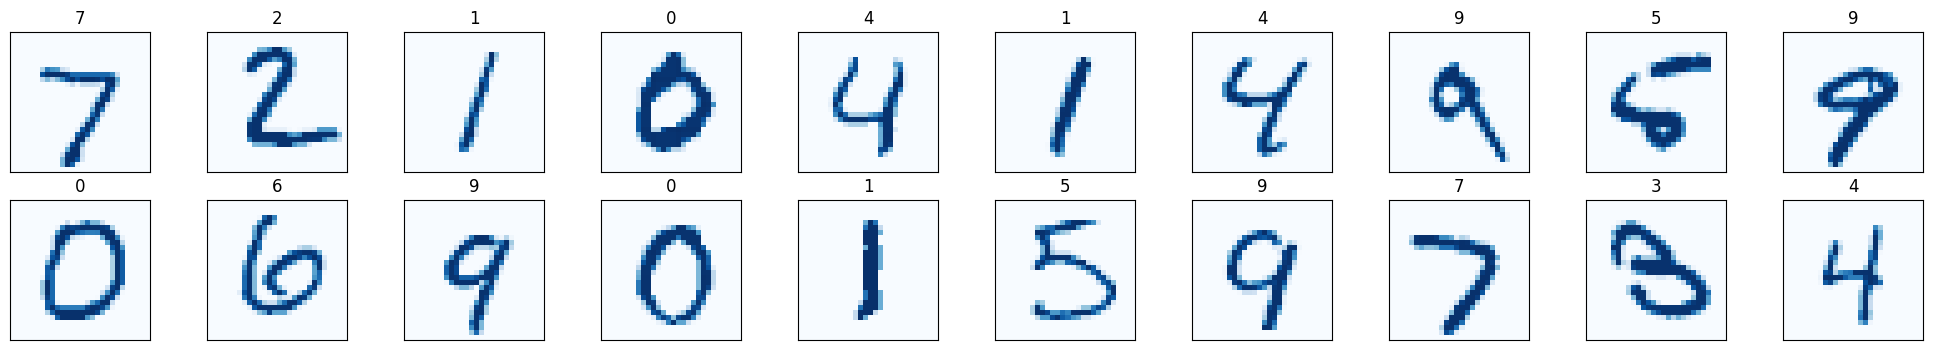

In [5]:
# If you use train_loader instead of test_loader, the images below 
# will change periodically due to shuffling (shuffle=True)
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    # If the colors in the illustrations below don't quite match
    # your sense of beauty, experiment with cmap :)
    ax.imshow(np.squeeze(images[idx]), cmap='Blues')
    ax.set_title(str(labels[idx].item()))

Let's examine the curvy six in detail:

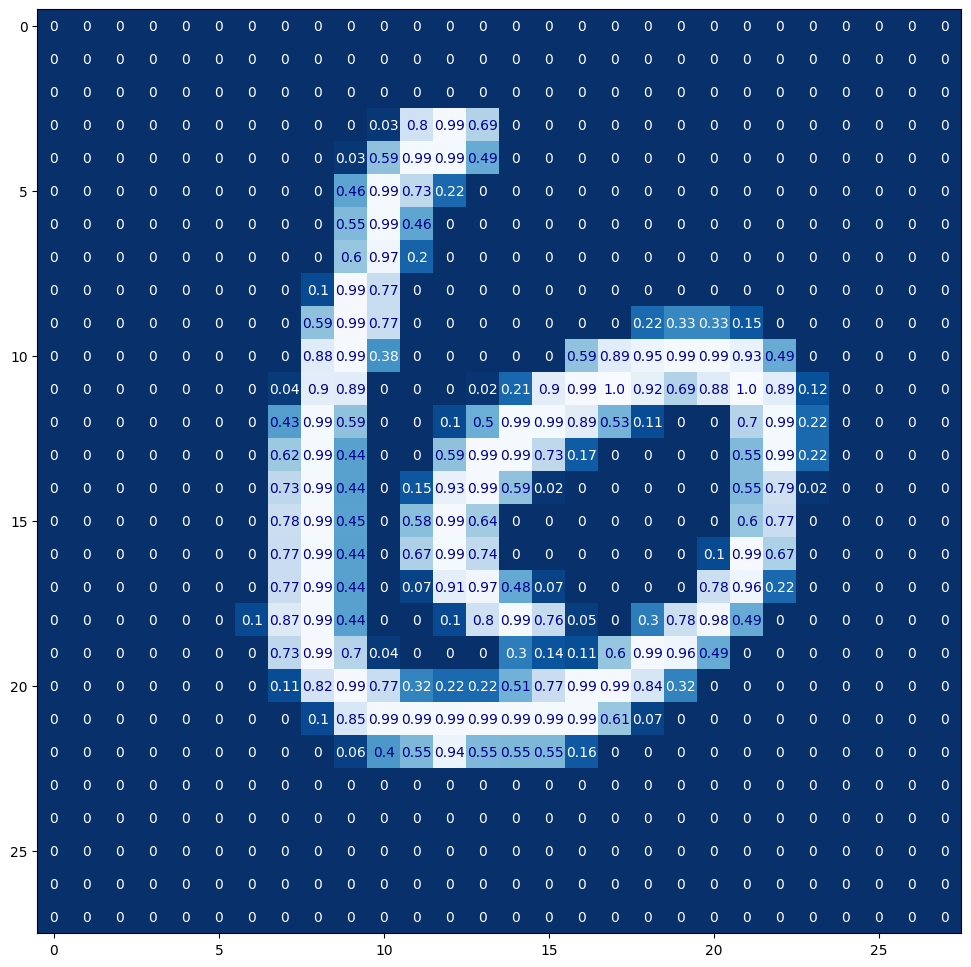

In [6]:
img = np.squeeze(images[11])

fig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
# Note that both here and above the "Blues" colormap is used, but adding "_r" inverts the colors. Handy!
ax.imshow(img, cmap='Blues_r')
width, height = img.shape

threshold = img.max()/2.5

for x in range(width):
    for y in range(height):
        val = round(img[x][y], 2) if img[x][y] != 0 else 0

        # Choose font color
        color = 'white' if img[x][y] < threshold else 'darkblue'

        # Display the cell
        ax.annotate(str(val), xy=(y, x), horizontalalignment='center', verticalalignment='center', color=color)

# Architecture Overview

As the [table](https://en.wikipedia.org/wiki/MNIST_database#Classifiers) rom Wikipedia with MNIST solution methods suggests, the architecture of our network should be either a [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron) (MLP, the simplest neural network), or a [Convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN). There is also a more detailed [table](https://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html), but that's worth diving into only after more thorough preparation.

I would like to take a slightly unconventional approach. Let's first work with a multilayer perceptron, then try to move on to a locally connected model (this is an intermediate step from MLP to CNN), and then switch to an actual CNN. I hope that experimenting with a locally connected neural network will help us understand the principles of convolutional neural networks more easily.

Well then, let's take the simplest option for our first experience — a perceptron.

The architecture for solving MNIST must accept an input tensor of length 28 * 28 = 784 and have an output tensor of length 10 — the number of classes the input image can belong to. We'll set the number of neurons in the hidden layer to 800, as recommended by the Wikipedia article mentioned above, which should give us an error of about 1.6% (i.e., out of 1000 images, 984 will be correctly recognized), which is quite good considering that the error rate for manual classification is also non-zero, and typically ranges, according to various sources, from 98.3% to 99.8% ("[Some cases of digits difficult to recognize, even for humans](https://www.mdpi.com/2076-3417/9/15/3169)").

Our neural network will be fully connected, meaning all neurons of the previous layer are connected to all neurons of the next layer.

# MLP

## MLP Code

In [7]:
# A neural network in PyTorch must inherit from nn.Module and have
# a 'forward' method that returns the model architecture
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        # Besides Sequential, you can use ModuleList and ModuleDict, but then the layer
        # interaction logic must be defined in the 'forward' method
        # All layers inside Sequential will be automatically connected sequentially,
        # perfect for a perceptron. Slightly simplifies the syntax
        self.layers = nn.Sequential(

            # Converts the input rectangular image into a long one-dimensional tensor without touching the batch axis
            nn.Flatten(),

            # Input layer. The number of inputs corresponds to the image resolution.
            # Linear = a "regular" neural network layer
            nn.Linear(28 * 28, 800),

            # A bit of nonlinear neural magic — the activation function. ReLU(x) = max(0, x). Without this element
            # the entire neural network would simply become a linear regression method
            nn.ReLU(),

            # At each training step, a portion of neurons from the previous layer can be disabled to prevent overfitting
            nn.Dropout(p=0.3),

            # Hidden layer
            nn.Linear(800, 800),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Output layer. The number of inputs equals the number of outputs from the previous layer,
            # and the number of outputs corresponds to the number of classes into which we classify the images
            nn.Linear(800, 10)
            # This is the perfect place for the softmax activation function, but it's already built into CrossEntropyLoss (see below)
        )
    
    def forward(self, x):
        return self.layers(x)

# Don't forget to use the GPU
model = Perceptron().to(device)

print(f"\nModel structure: {model}\n\n")

# If you want to see what's inside the model, uncomment the code below
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: Perceptron(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=800, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=800, out_features=800, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=800, out_features=10, bias=True)
  )
)




## Model Visualization

Model visualization using [PyTorchViz](https://github.com/szagoruyko/pytorchviz).

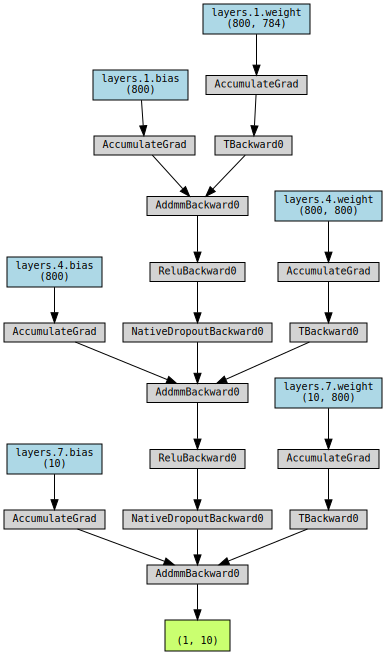

In [8]:
# We feed a test tensor into our neural network so that PyTorchViz can analyze its internal structure
x = torch.randn(1, 28 * 28).to(device)

make_dot(model(x), params=dict(model.named_parameters()))

## MLP Configuration

If you uncomment the line "print(f"Layer: {name} Size: {param.size()..." in the code above, you will see that immediately after initialization the layers are already filled with some [coefficients](https://en.wikipedia.org/wiki/Weight_initialization). Why not zeros? The explanation is here — "[An Explanation of Xavier Initialization](https://andyljones.tumblr.com/post/110998971763/an-explanation-of-xavier-initialization)", and the specific code is — [right here](https://github.com/pytorch/pytorch/blob/099a6d5e083d78e04437a22e7cf963c4e0a1fa18/torch/nn/modules/linear.py#L48-L52) (search the page for def reset_parameters if the code gets reformatted after some commit).

Choosing the loss function:

In [9]:
criterion = nn.CrossEntropyLoss()

Choosing the optimization function:

In [10]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## MLP Training

In [11]:
# Number of epochs
n_epochs = 32

# Empty list for the future plot
train_loss_curve = []

def model_train():
    # Enable specific layers (Dropout, BatchNorm) used only during training. Even if such layers are absent,
    # still use model.train() so that later, when adding them, you won't have to hunt for bugs
    model.train()

    # Measure the training duration
    start = time.time()

    # Create a progress bar
    pbar = tqdm.tqdm(range(1, n_epochs + 1))

    for epoch in pbar:
        train_loss = 0.0  # Monitor the loss

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Clear old gradients. You can also work with gradient accumulation, but that trick is not for this (standard) situation
            optimizer.zero_grad()

            # Forward pass, the model processes data using current parameters
            outputs = model(images)

            # Calculate the loss
            loss = criterion(outputs, labels)

            # Compute new gradients. Under the hood: backpropagation = computing partial derivatives with respect to each parameter
            loss.backward()

            # Update all model weights
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        # Calculate the average loss for the epoch
        train_loss = train_loss/len(train_loader.dataset)
        train_loss_curve.append(train_loss)
        pbar.set_description(f'Epoch {epoch}  \tTraining Loss: {train_loss:.4f}')

    end = time.time()
    print(f"\nElapsed time: {str(datetime.timedelta(seconds=round(end-start)))}")

model_train()

Epoch 32  	Training Loss: 0.0362: 100%|██████████| 32/32 [05:05<00:00,  9.54s/it]


Elapsed time: 0:05:05


Of course, you can build in a condition to stop training once the desired result is achieved.

## MLP Loss Plot

Let's see how the loss behaves:

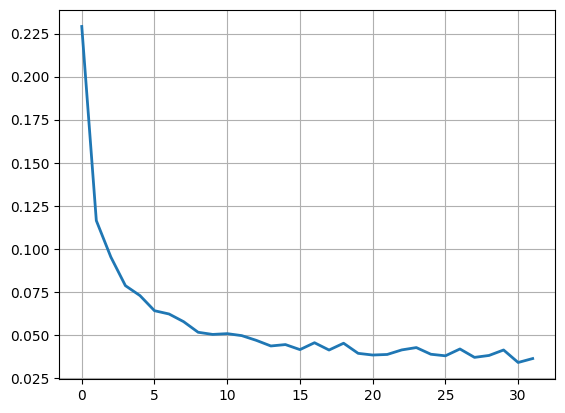

In [12]:
plt.plot(train_loss_curve, linewidth=2)
plt.grid(True)
plt.show()

Notice the accuracy jump after just the first epoch — from 10% (a classifier with 10 outputs and random internal weights → accuracy = 100% / 10) to ~80%!

Note that if earlier in response to print(f'Using {device} device') you saw Using cuda device, then the CPU load should be fairly low, while the GPU/CUDA load should be quite substantial. If the model didn't "latch onto" the GPU (this happened to me during my studies due to minor code typos), you will see heavy CPU load. The fact that PyTorch "sees" the GPU and CUDA does not mean it will use them by default; you need to use .to(device) appropriately, otherwise you may get low GPU utilization, significantly increased model computation time, and even errors like RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu.

## MLP Testing

Model testing must always be performed on validation data that differs from the training data. In general, validation data does indirectly seep into your model's hyperparameters (number, size, and type of layers, batch size, regularization coefficients, etc. — in short, everything that is determined before training begins), because each time you get an unsatisfactory result, you start tweaking hyperparameters, thereby inadvertently incorporating validation data into the model architecture. Therefore, for experimental purity, the entire dataset should be split into training, validation, and control data; the control data is kept "secret" from the model and is used for the very last, final check. But right now we won't bother with that for the sake of process transparency.

In [13]:
def model_eval():
    # Disable Dropout and BatchNorm layers used only during training.
    # Just as with model.train(), always switch the model to eval()
    model.eval()

    correct = 0
    total = 0
    
    # Disable backward pass and gradient computation, saving memory and processing time
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

model_eval()

Accuracy: 98.29%


# Saving and Loading Models

Now that the model is trained and tested, we can save it to disk. Our example is simple, and training doesn't take too long, but hopefully that won't last — the more complex the models you work with, the more time, hardware resources, and mental energy will go into training and fine-tuning them, so it's better to learn how to store models somewhere right away.

Let's estimate the size of the resulting model. This will also be useful for later comparison with CNN.

The number of weights in one fully connected linear layer = number of inputs × number of outputs + number of outputs (accounting for bias).

(784 * 800 + 800) + (800 * 800 + 800) + (800 * 10 + 10) = 1,276,810 weights.

Let's verify:

In [14]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 1276810


Weights are stored in float32 format, totaling 1,276,810 × 4 bytes = 5,107,240 ≈ 4.87 MiB

Save the model:

In [15]:
# Save only the model weights
torch.save(model.state_dict(), 'model_weights.pth')

# You can save the entire model (both structure and weights), but this is not recommended
# torch.save(model, 'full_model.pth')

The resulting file size is also ≈ 4.87 MiB, only a few KiB larger due to metadata overhead.

Load the model weights:

In [16]:
model.load_state_dict(torch.load('model_weights.pth'))

<All keys matched successfully>

MLP summary for MNIST recognition:
• fully connected model;  
• architecture 784-800-10;  
• accuracy 98.3%;  
• size 4.87 MiB;  
• training time 2 minutes 47 seconds.

# Model Visualization 2

After saving the model, you can also apply another quite popular visualization tool — [Netron](https://github.com/lutzroeder/netron).  For the full model, the picture will look approximately like this:

<img src= "https://raw.githubusercontent.com/amaargiru/kaggle-notebooks/refs/heads/main/images/01-PyTorch-MLP-CNN-MNIST-for-beginners/full_model.pth.png" alt ="Full model" style='width: 410px;'>

# Locally Connected Network

Before moving on to the actual convolutional network, let's try to take one step that, while not particularly efficient in terms of accuracy for the task at hand, will somewhat deepen our understanding of convolutional networks. After all, right now we could simply plug in PyTorch's built-in convolutional layers, and the code would look roughly the same as the previous model, giving us knowledge about using built-in functionality — that is, roughly nothing. Let's write our own analogue of a convolutional network ourselves, then the resulting code can give us a somewhat deeper understanding of what's happening, convolution will stop being magic and become simply a tool.

Let's reason through this.

The number of weights in the first layer of neurons of a fully connected network is 784 × 800 (excluding bias), totaling 627,200. At the same time, for image recognition it makes sense to primarily analyze elements located in close proximity. For example, for an input image of 28 × 28 pixels, you could try analyzing "squares" of, say, 2 × 2, 3 × 3, or 4 × 4 pixels, attempting to extract information corresponding not just to individual pixels but to their groups.

This is called a locally connected layer. Imagine that the first neuron of the first hidden layer receives connections not from all 784 input neurons, but only from 9 — from a 3 × 3 square located in the top-left corner of the image. Next, the second hidden neuron receives 9 connections from a 3 × 3 square shifted one pixel to the right from the start of the image, and so on.

A locally connected layer is not included in the standard PyTorch package set, but fortunately, people sometimes feel the urge to experiment, so an implementation of a locally connected layer can still be found.

## Locally Connected Network Code

In [17]:
# Locally connected layer class. PyTorch does not have an implementation of such a layer, so we implement the logic ourselves
class LocallyConnected2d(nn.Module):
    def __init__(self, in_channels, out_channels, input_height, input_width, kernel=3, stride=1):
        super().__init__()
        # Kernel size
        self.kernel = kernel
        
        # Stride step
        self.stride = stride

        # There should also be padding here to allow preserving the image size, as in "real" CNNs, but for our educational example it'll do
        self.out_height = (input_height - kernel) // stride + 1
        self.out_width = (input_width - kernel) // stride + 1

        # Kaiming initialization. You could also use the more straightforward nn.init.kaiming_normal_,
        # but for our non-standard architecture additional code would be needed
        self.weight = nn.Parameter(torch.randn(self.out_height, self.out_width, out_channels, in_channels * kernel ** 2) * (2.0 / (in_channels * kernel ** 2)) ** 0.5)

        # bias should be initialized with zeros
        self.bias = nn.Parameter(torch.zeros(self.out_height, self.out_width, out_channels))

        # If the code below isn't entirely clear — don't worry, this is just a concept
        # intended to demonstrate that behind every PyTorch method lies concrete mathematics,
        # and that sometimes you can implement the functionality you need bypassing the standard approaches
    def forward(self, x):
        # Slide a kernel × kernel window across height (axis 2) and width (axis 3) with the given stride
        # We get all patches — cropped image fragments matching the kernel size, to which weights will be applied
        patches = x.unfold(2, self.kernel, self.stride).unfold(3, self.kernel, self.stride)

        # Rearrange axes: move spatial coordinates (h, w) to the second and third positions,
        # and channels and patch pixels to the end. contiguous() rearranges data in memory to match the new order
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()

        # Flatten channels and pixels of each patch into one long vector
        # Now each patch is simply a list of numbers ready to be multiplied by weights
        patches = patches.view(x.size(0), self.out_height, self.out_width, -1)

        # For each position (h, w), multiply its patch by its own weights — not shared across the entire map
        # This is exactly where local connectivity lies: each position has its own independent set of weights
        out = torch.einsum('bhwi,hwoi->bhwo', patches, self.weight) + self.bias

        # Return channels to the second position — bring the tensor back to the standard format (batch, channels, height, width)
        # This is needed so that the next layer receives data in the axis order expected by PyTorch
        return out.permute(0, 3, 1, 2)

class LocallyConnectedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lc1 = LocallyConnected2d(1, 16, 28, 28)
        self.lc2 = LocallyConnected2d(16, 32, 13, 13)
        self.fc1 = nn.Linear(32 * 5 * 5, 128)  #  "Regular" fully connected layer for image classification 800 -> 128
        self.fc2 = nn.Linear(128, 10)  # "Regular" fully connected output layer 128 -> 10

    def forward(self, x):
        x = self.lc1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # Take the maximum in each 2×2 window, size is halved. We won't write max_pool2d ourselves; it's a standard PyTorch layer

        # There may be pixel loss here with odd image dimensions (due to integer division in the LocallyConnected2d code), but for MNIST everything works

        x = self.lc2(x)         # Second locally connected layer, 32 output channels
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # Again halve the size (11//2 = 5)

        x = x.flatten(1)        # Flatten 32×5×5 into a flat tensor of length 800, merging all tensor axes except the zeroth
        x = self.fc1(x)         # 128 fully connected neurons, 800 → 128
        x = F.relu(x)

        x = self.fc2(x)         # Fully connected layer 128 → 10
        return x                # Return logits (Softmax will be applied later, when computing the loss function)

In [18]:
model = LocallyConnectedNet().to(device)

print(f"\nModel structure: {model}\n\n")
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: LocallyConnectedNet(
  (lc1): LocallyConnected2d()
  (lc2): LocallyConnected2d()
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)




## Locally Connected Network Training

The training code and the accuracy measurement code for the locally connected model are no different from the fully connected model code — we just redefine the optimization function and reuse the main code:

In [19]:
# At this stage, by the way, you can connect different optimizers for different model layers or "freeze" some layers
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model_train()

Epoch 32  	Training Loss: 0.0091: 100%|██████████| 32/32 [05:46<00:00, 10.83s/it]


Elapsed time: 0:05:47


## Comparing Loss Plots

On the combined loss plot I highlighted the new data with a yellow rectangle:

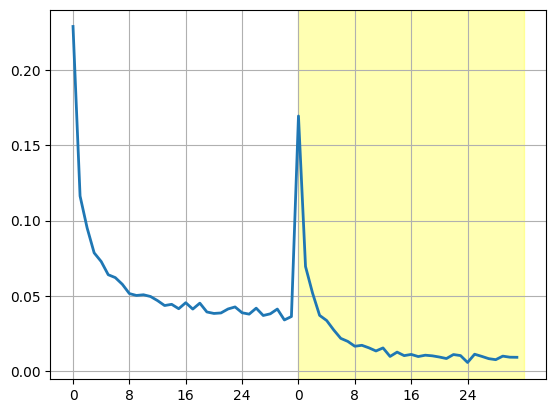

In [20]:
# A bit of trickery so that the right half of the plot also visually counts from zero
x_positions = list(range(0, n_epochs)) + list(range(n_epochs, 2 * n_epochs))

plt.plot(x_positions, train_loss_curve, linewidth=2)

x_ticks = list(range(0, 2 * n_epochs, n_epochs // 4))
x_labels = [str(i % n_epochs) for i in x_ticks]

plt.xticks(x_ticks, x_labels)

# Highlight the second half of the plot
plt.axvspan(n_epochs, 2 * n_epochs, color='yellow', alpha=0.3)

plt.grid(True)
plt.show()

I deliberately didn't clear the train_loss_curve list from the previous values obtained during fully connected network training. Notice how the loss of the locally connected network (highlighted in yellow) decreases compared to the fully connected network.

Measuring model accuracy:

In [21]:
model_eval()

Accuracy: 98.85%


Our custom architecture uses GPU resources quite inefficiently, so the training time is unlikely to decrease compared to MLP, but the number of parameters has decreased significantly:

In [22]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 773418


And this is with equal or even slightly better accuracy.

# CNN, Convolutional Neural Network

## CNN Code

Here is the convolutional network code for solving MNIST:

In [23]:
class CNN_Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

Thanks to the previous analysis of the locally connected network, the operating principle of the nn.Conv2d layer becomes somewhat clearer.

In [24]:
model = CNN_Net().to(device)

print(f"\nModel structure: {model}\n\n")
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: CNN_Net(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=800, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)




## CNN Training

And once again we reuse the training code:

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# We'll discuss this line a little below
cudnn.benchmark = True

model_train()

Epoch 32  	Training Loss: 0.0019: 100%|██████████| 32/32 [05:15<00:00,  9.87s/it]


Elapsed time: 0:05:16


## Comparing Loss Plots of Three Models

The final plot — now the CNN loss is highlighted in yellow.

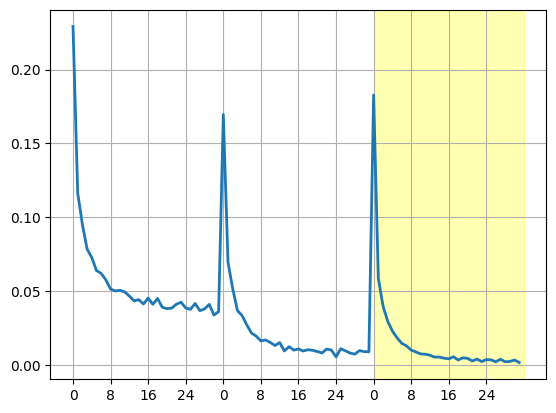

In [26]:
x_positions = list(range(0, n_epochs)) + list(range(n_epochs, 3 * n_epochs))

plt.plot(x_positions, train_loss_curve, linewidth=2)

x_ticks = list(range(0, 3 * n_epochs, n_epochs // 4))
x_labels = [str(i % n_epochs) for i in x_ticks]

plt.xticks(x_ticks, x_labels)

# Highlight the last third of the plot
plt.axvspan(2 * n_epochs, 3 * n_epochs, color='yellow', alpha=0.3)

plt.grid(True)
plt.show()

Accuracy:

In [27]:
model_eval()

Accuracy: 98.84%


In [28]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 108618


# CNN Implementation Details

So, OK, we can see that all the code works correctly, and the error consistently decreases as we move in the direction of MLP -> locally connected layers -> CNN. Now let's go over the principles of how a convolutional neural network works one more time to reinforce our understanding.

When discussing convolutional neural networks, people often use a simplification for clarity that has already become a common expression and is frequently used without the undertone of a "metaphor" — which is something we should nevertheless avoid.

This simplification is: "a mask slides across the input image." In reality, no mask slides anywhere. This is merely a visual concept intended to explain the basic principles of convolution. You will never see code like this in practice, because while the result would be correct, it would be catastrophically slow:
```
for b in range(B):                           # Batches
    for co in range(C_out):                  # Output channels
        for i in range(H_out):               # Output height
            for j in range(W_out):           # Output width
                for ci in range(C_in):       # Input channels
                    for ki in range(KH):     # Kernel height
                        for kj in range(KW): # Kernel width
                            output[b, co, i, j] += (input[b, ci, i * stride + ki, j * stride + kj] * kernel[co, ci, ki, kj])
```

"A mask slides across" describes fairly accurately what is being computed, but does not reflect at all how the actual computation takes place. Real convolution — in the simplest case — is essentially a clever repacking of data followed by a single large matrix multiplication, which allows for proper utilization of GPU parallelism.

There are several main approaches to fast convolution implementation, and PyTorch, in turn, has a built-in mechanism for selecting the fastest method, which relies on the model parameters and available hardware resources. To make PyTorch remember the result of this selection and avoid repeating the procedure (since the selection process carries some overhead — it is not simply an if-else block but more like a benchmarking test), you can use the flag mentioned earlier:

In [29]:
cudnn.benchmark = True

So what options does PyTorch consider?

The most popular method is called im2col + GEMM. It extracts all patches from the image (rectangular fragments matching the size of the kernel) and then "unrolls" the set of patches into a matrix where the number of rows equals the length of a patch (for example, if the kernel is three by three with three input channels, each column will contain twenty-seven numbers), and the number of columns equals the number of patches. The convolution kernel, in turn, is unrolled into a single-row matrix, after which the matrices are multiplied.

Let's look at an example using a simple 4×4 image and a 2×2 kernel.

Input image 4×4:
```
a  b  c  d
e  f  g  h
i  j  k  l
m  n  o  p
```

Kernel 2 * 2:
```
w1  w2
w3  w4
```

Transform the input image into a matrix M1 as follows (this step of the algorithm is called im2col — image to column):
```
a  b  c  e  f  g  i  j  k
b  c  d  f  g  h  j  k  l
e  f  g  i  j  k  m  n  o
f  g  h  j  k  l  n  o  p
```

Notice the repeated values in the unrolled patch matrix. This is a memory overhead that is paid in exchange for the ability to reduce convolution to a single large and fast matrix multiplication.

The kernel, in turn, is unrolled into a row M2:
```
w1  w2  w3  w4
```

Multiply (here GEMM — General Matrix Multiply — is applied):
```
М1 * М2 = row (1 * 9)
```

Each element of the result is a dot product of the kernel row and the corresponding column. For example, the first element equals w1·a + w2·b + w3·e + w4·f.

The trick is that GEMM is an incredibly fast algorithm that squeezes every last drop out of your computer's hardware capabilities. Assembly code, optimal use of processor cache, SIMD instructions, GPU hardware utilization, GPU parallelism — all of this is already baked into GEMM, carefully optimized, and tuned for one thing only: speed. Once you have managed to reduce your problem to matrix multiplication — that's it, just fire up the thermonuclear chainsaw that is GEMM and step aside so you don't get splattered.

And returning to our practical exercises — the resulting row of 9 numbers is reshaped back into a 3×3 matrix — and that is your output feature map.

In addition to the im2col + GEMM combination, there are more exotic convolution methods that appear more heavyweight but are successfully used by PyTorch on certain types of data. For example, the **FFT** (Fast Fourier Transform) algorithm, which moves computations into the frequency domain and provides a speed advantage when working with large kernel sizes; or the **Winograd** algorithm, optimized for a kernel size of 3×3, which, like FFT, transforms matrices into a special basis where convolution is replaced by element-wise multiplication.

# Conclusion

That's all for now. I hope this guide has been useful to you and that you now have a slightly better understanding of how convolutional neural networks work.

If you are more comfortable working with GitHub, here is the address of this article there — [Understanding CNN Principles for Beginners | PyTorch | MNIST](https://github.com/amaargiru/kaggle-notebooks/blob/main/01-PyTorch-MLP-CNN-MNIST-for-beginners/01-PyTorch-MLP-CNN-MNIST-for-beginners.ipynb).

Remember that the main learning tool is the code inside the notebooks. Something unclear? Found a error? Have something to add? Be sure to copy the notebook and test your assumptions by modifying and running the code.